In [1]:
import sys
sys.path.insert(0,'../scripts')
from pycap_for_PESTPP_MOU import postprocess_MOU, plot_pareto, prep_for_viz, create_viz_app, plot_pareto_with_scenarios
from pathlib import Path
from ipywidgets import interact, fixed
import yaml
import pandas as pd
import pyemu
import matplotlib.pyplot as plt

# Read in one of the configuration files and postprocess it. 
### The `config_file` should be your `secnario_name` + `".yml"`
#### as assigned in the `05_MOU_setup_run.ipynb` notebook. 

In [2]:
configurations = ['fish_dollars_baseline_0.0_1.0_0.2', 'fish_dollars_Tmin10per_0.0_1.0_0.2', 'fish_dollars_Tplus10per_0.0_1.0_0.2']
configurations = ['fish_dollars_baseline_0.0_1.0_0.01', 'fish_dollars_Tmin10per_0.0_1.0_0.01', 'fish_dollars_Tplus10per_0.0_1.0_0.01']
config = configurations[-1]  # Select the desired configuration
config_file = config + '.yml'

with open(Path('./configurations') / config_file,'r') as ifp:
    inpars = yaml.safe_load(ifp)
inpars

{'depletion_potential_threshold': 0.01,
 'objectives': 'fish_dollars',
 'pump_lbound_fraction': 0.0,
 'pump_ubound_fraction': 1.0,
 'ref_q': 8.6,
 'run_path': '../pycap_runs/pycap_pest/run_fish_dollars_Tplus10per_0.0_1.0_0.01',
 'scenario_name': 'fish_dollars_Tplus10per_0.0_1.0_0.01'}

### Below, the `config_file` is processed, beginning the postprocessing

In [3]:
run_path = Path(inpars['run_path'])
run_name = inpars['scenario_name']
pareto_df = postprocess_MOU(run_name, run_path)

In [4]:
# interact(plot_pareto,  currgen=(0,50,1), pareto_df=fixed(pareto_df))

In [5]:
pareto_df= pareto_df.loc[pareto_df.generation == 50]
# pareto_df

___
### Let's scrape through all the results and see what happens if we also evaluate total pumping and streamflow objectives

In [6]:
# get all the observations files - beware of some python shenanigans here!
# this reads in the observations for ALL model simulations - probably more than 10,000
obs_df = pd.concat([pd.read_csv(i, index_col=0) for i in run_path.glob("*obs_pop*")])

In [7]:
# the three columns we want are "ag_receipts","fish_prob", and "lpr:total_combined:bdpl" (that last one is the total depletion)
# and, we can use the indices from the pareto_df to keep track of the final realizations
obs_df.index = obs_df.index.astype(str)
obs_df = obs_df.loc[pareto_df.member, ["ag_receipts","fish_prob", "lpr:total_combined:bdpl"]].drop_duplicates()
obs_df.sample(10)

,ag_receipts,fish_prob,lpr:total_combined:bdpl
real_name,,,
gen=34_member=4316_pso,1.110401e+07,0.708944,1.996367
gen=50_member=6351_pso,1.028549e+07,0.716300,1.641110
gen=48_member=6133_pso,1.229242e+07,0.564948,4.485382
gen=35_member=4389_pso,1.215087e+07,0.622524,3.813050
gen=37_member=4658_pso,9.774834e+06,0.717912,1.534739
gen=50_member=6323_pso,1.140778e+07,0.702849,2.225158
gen=42_member=5280_pso,1.177272e+07,0.690490,2.611751
gen=45_member=5732_pso,1.219142e+07,0.611616,3.955917
gen=39_member=4921_pso,1.212335e+07,0.636239,3.633413


In [8]:
# similarly for pumping
dv_df = pd.concat([pd.read_csv(i, index_col=0) for i in run_path.glob("*dv_pop*")]).loc[obs_df.index].drop_duplicates()
dv_df.sample(10)

,well_1013__q,well_1302__q,well_1323__q,well_1486__q,well_1584__q,well_1589__q,well_1643__q,well_1683__q,well_1860__q,well_23610__q,...,well_93143__q,well_93349__q,well_93422__q,well_93423__q,well_93424__q,well_93469__q,well_93832__q,well_94302__q,well_94988__q,well_95068__q
real_name,,,,,,,,,,,,,,,,,,,,,
gen=25_member=3145_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=48_member=6133_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=47_member=5954_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=41_member=5148_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=32_member=4008_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=49_member=6267_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=42_member=5363_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
35,125.1,88.2,76.2,240.105198,167.951555,264.1,114.5,260.6,195.7,239.024202,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3
gen=47_member=6006_pso,125.1,88.2,76.2,222.800000,150.500000,264.1,114.5,260.6,195.7,201.700000,...,0.6,27.2,0.1,0.1,0.2,158.2,14.6,148.9,11.1,40.3


In [9]:
# dv_df.sum(axis=1)

In [10]:
#Tricky thing is, for receipts case, if pumping drops below 70% of the original value, 
# it goes to zero, so let's adjust
# first we need those original pumping values
pst = pyemu.Pst(str(run_path / f"{run_name}.pst"))
pars = pst.parameter_data

In [11]:
# next for each well, we need to adjust, but only of "dollar" is in the objectives
dollars=False
if 'dollar' in inpars['objectives']:
    dollars = True
if dollars is True:
    for cc in dv_df.columns:
        dv_df.loc[dv_df[cc]<=pars.loc[cc,'parval1']*.7,cc]=0

### Finally, sum up all the pumping and the result is 4 columns that can be plotted against each other

In [12]:
obs_df['pumping_sum'] = dv_df.sum(axis=1).loc[obs_df.index]
obs_df.columns

Index(['ag_receipts', 'fish_prob', 'lpr:total_combined:bdpl', 'pumping_sum'], dtype='object')

In [13]:
new_df2 = obs_df.copy()

# rename columns
new_df2 = new_df2.rename(columns={
    "ag_receipts": "Total Agriculture Receipts ($)",
    "fish_prob": "Trout Likelihood (%)",
    "pumping_sum": "Total Pumping (gpm)",
    "lpr:total_combined:bdpl": "Depletion (cfs)",
})

new_df2.insert(2, "Streamflow (cfs)", 8.6 - new_df2["Depletion (cfs)"])
new_df2["Total Pumping (cfs)"] = new_df2["Total Pumping (gpm)"] * 0.0022280093

# new_df2.columns
new_df2[[new_df2.columns[-1], new_df2.columns[2], new_df2.columns[3]]].to_csv(f'{config}_tradeoff.csv')


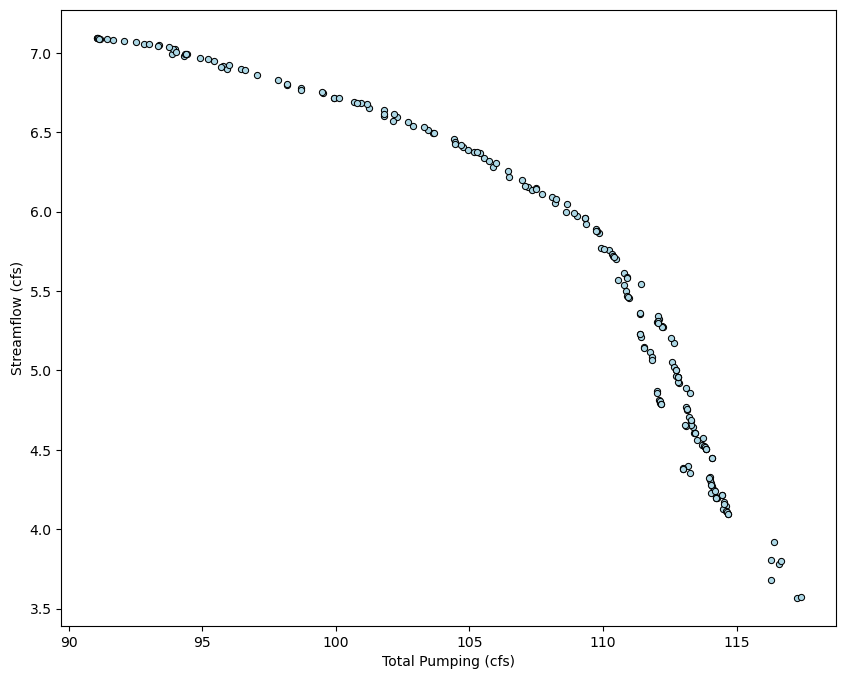

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(new_df2["Total Pumping (cfs)"], new_df2["Streamflow (cfs)"], marker="o", s=20, c="lightblue", edgecolors="black", linewidths=0.75)
ax.set_xlabel("Total Pumping (cfs)")
ax.set_ylabel("Streamflow (cfs)")
plt.show()

In [15]:
new_df2[new_df2["Depletion (cfs)"] <= 3.75].sort_values(by="Depletion (cfs)", ascending=False)

,Total Agriculture Receipts ($),Trout Likelihood (%),Streamflow (cfs),Depletion (cfs),Total Pumping (gpm),Total Pumping (cfs)
real_name,,,,,,
gen=47_member=5954_pso,1.214554e+07,0.627890,4.857225,3.742775,50829.449509,113.248486
gen=34_member=4243_pso,1.213795e+07,0.627949,4.857999,3.742001,50285.756081,112.037132
gen=33_member=4208_pso,1.213395e+07,0.629030,4.872169,3.727831,50269.469904,112.000846
gen=28_member=3529_pso,1.213246e+07,0.630086,4.885991,3.714009,50773.152017,113.123055
gen=49_member=6177_pso,1.213067e+07,0.632815,4.921735,3.678265,50646.503212,112.840880
...,...,...,...,...,...,...
gen=31_member=3866_pso,9.565192e+06,0.718196,7.089647,1.510353,40919.497748,91.169022
gen=35_member=4391_pso,9.555703e+06,0.718200,7.089938,1.510062,40898.417735,91.122055
gen=43_member=5397_pso,9.538553e+06,0.718222,7.091837,1.508163,40893.796186,91.111758
